# Paying More for Emptier Branches
### Tayseer's branch network is shrinking in use but not in cost

**Course:** Data Visualization and Storytelling (SDAIA Academy)  
**Student:** Abdullah Sultan Alotaibi  
**Data:** `tayseer_services.csv`, monthly, Jul 2021 – Jun 2026, 13 regions × 9 service categories × 4 channels

## Decision question
> **Should the Steering Committee keep funding the branch network at its current size, or order a review to resize it before the next budget?**

| | |
|---|---|
| **Audience** | Tayseer Program Steering Committee (budget owners) |
| **Scope** | Branch channel vs the other three channels, all regions and categories, program years Jul 2021 – Jun 2026 |

## 1. Setup and load the data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CSV = "tayseer_services.csv"
DRIVE_ID = "1HIimBlNb-15QX46qg9FPy0rA5hoLlMg6"   # copy of the dataset on Google Drive

# In Colab: if the CSV is not next to the notebook, download it from Drive
if not os.path.exists(CSV):
    import gdown                                    # pre-installed in Colab
    gdown.download(id=DRIVE_ID, output=CSV, quiet=False)

df = pd.read_csv(CSV, parse_dates=["month"])
os.makedirs("charts", exist_ok=True)
print(df.shape)
df.head()

(28080, 12)


,month,region,service_category,channel,transactions,unique_users,digital_adoption_pct,avg_completion_min,cost_per_txn_sar,csat,sla_met_pct,complaints
0,2021-07-01,Al-Baha,Business & Licensing,Branch,5727,4745,33.4,117.0,51.88,3.05,80.7,10
1,2021-07-01,Al-Baha,Business & Licensing,Call Center,2575,1708,33.4,31.5,24.11,3.57,93.2,2
2,2021-07-01,Al-Baha,Business & Licensing,Mobile App,1936,721,33.4,13.7,6.26,4.13,96.2,1
3,2021-07-01,Al-Baha,Business & Licensing,Web Portal,2425,1221,33.4,19.4,8.63,3.85,94.9,3
4,2021-07-01,Al-Baha,Education & Training,Branch,7443,5923,37.0,29.4,39.00,3.55,84.4,7


In [2]:
# Chart style: strong, clearly different colours
CHANNEL_COLORS = {
    "Branch":      "#D62728",   # red    = the story
    "Call Center": "#9467BD",   # purple
    "Web Portal":  "#1F77B4",   # blue
    "Mobile App":  "#2CA02C",   # green
}
TX_COLOR   = "#1F77B4"   # blue   = share of transactions (chart 2)
COST_COLOR = "#FF7F0E"   # orange = share of cost (chart 2)
DARK = "#3A3A3A"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#888888", "axes.labelcolor": DARK,
    "xtick.color": "#555555", "ytick.color": "#555555",
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def add_titles(fig, title, subtitle, x=0.01):
    # takeaway title (bold) + one quiet line explaining the metric
    top = fig.axes[0].get_position().y1
    fig.text(x, top + 0.085, title, ha="left", va="bottom", fontsize=19, weight="bold", color="#1A1A1A")
    fig.text(x, top + 0.04, subtitle, ha="left", va="bottom", fontsize=10.5, color="#555555")

## 2. Check the data

In [3]:
print("Missing values:", int(df.isna().sum().sum()))
print("Months:", df.month.nunique(), f"({df.month.min():%b %Y} – {df.month.max():%b %Y})")
print("Regions:", df.region.nunique(), "| Categories:", df.service_category.nunique(),
      "| Channels:", sorted(df.channel.unique()))
rows = df.groupby(["month", "region", "service_category", "channel"]).size()
assert (rows == 1).all()
print("OK: exactly one row per month x region x category x channel")

Missing values: 0
Months: 60 (Jul 2021 – Jun 2026)
Regions: 13 | Categories: 9 | Channels: ['Branch', 'Call Center', 'Mobile App', 'Web Portal']
OK: exactly one row per month x region x category x channel


**Metrics and aggregation**

- **Visits / transactions:** `transactions` is a count, so it is **summed**.
- **Cost per transaction:** `cost_per_txn_sar` is an average for each row, so rows cannot be averaged directly.
  I rebuild the total cost of each row (`cost_per_txn_sar × transactions`), sum it, and divide by summed transactions.
  This is a **transaction-weighted average** (total cost ÷ total transactions).
- **Share of cost:** each channel's total cost ÷ total cost of all channels.
- **Program year (PY):** July to June, so the 60 months form 5 full years: PY 2021-22 … PY 2025-26.
- `digital_adoption_pct` is not used, so its repeated values cannot cause double counting.

In [4]:
df["total_cost"] = df["cost_per_txn_sar"] * df["transactions"]
start = np.where(df.month.dt.month >= 7, df.month.dt.year, df.month.dt.year - 1)
df["program_year"] = [f"{y}-{str(y + 1)[-2:]}" for y in start]

py = (df.groupby(["program_year", "channel"])[["transactions", "total_cost"]].sum())
py["cost_per_txn"] = py.total_cost / py.transactions
py["share_of_txn_%"]  = py.transactions / py.groupby("program_year").transactions.transform("sum") * 100
py["share_of_cost_%"] = py.total_cost   / py.groupby("program_year").total_cost.transform("sum") * 100
py.round(2)

transactions    total_cost  cost_per_txn  \
program_year channel                                                 
2021-22      Branch           56161023  2.426399e+09         43.20   
             Call Center      26011424  5.217354e+08         20.06   
             Mobile App       22822481  1.010293e+08          4.43   
             Web Portal       24999649  1.680229e+08          6.72   
2022-23      Branch           49963284  2.263447e+09         45.30   
             Call Center      26627299  5.500760e+08         20.66   
             Mobile App       32292929  1.419527e+08          4.40   
             Web Portal       27715865  1.873180e+08          6.76   
2023-24      Branch           40577847  1.906453e+09         46.98   
             Call Center      24554106  5.226561e+08         21.29   
             Mobile App       44256888  1.919788e+08          4.34   
             Web Portal       29876751  2.023107e+08          6.77   
2024-25      Branch           33837772  1.663120e+09         49.15   
             Call Center      23361952  5.113109e+08         21.89   
             Mobile App       56535039  2.431295e+08          4.30   
             Web Portal       29824096  2.023300e+08          6.78   
2025-26      Branch           30198858  1.540223e+09         51.00   
             Call Center      23654653  5.281520e+08         22.33   
             Mobile App       67002232  2.819076e+08          4.21   
             Web Portal       26811370  1.804625e+08          6.73   

                          share_of_txn_%  share_of_cost_%  
program_year channel                                       
2021-22      Branch                43.20            75.42  
             Call Center           20.01            16.22  
             Mobile App            17.56             3.14  
             Web Portal            19.23             5.22  
2022-23      Branch                36.58            72.02  
             Call Center           19.49            17.50  
             Mobile App            23.64             4.52  
             Web Portal            20.29             5.96  
2023-24      Branch                29.14            67.52  
             Call Center           17.63            18.51  
             Mobile App            31.78             6.80  
             Web Portal            21.45             7.17  
2024-25      Branch                23.57            63.48  
             Call Center           16.27            19.52  
             Mobile App            39.38             9.28  
             Web Portal            20.77             7.72  
2025-26      Branch                20.45            60.86  
             Call Center           16.02            20.87  
             Mobile App            45.37            11.14  
             Web Portal            18.16             7.13

In [5]:
FIRST, LAST = "2021-22", "2025-26"
b0, b1 = py.loc[(FIRST, "Branch")], py.loc[(LAST, "Branch")]
visits_change = (b1.transactions / b0.transactions - 1) * 100
cost_change   = (b1.cost_per_txn / b0.cost_per_txn - 1) * 100
print(f"Branch visits      : {b0.transactions/1e6:.1f}M (PY {FIRST}) -> {b1.transactions/1e6:.1f}M (PY {LAST})  = {visits_change:+.0f}%")
print(f"Branch cost / visit: SAR {b0.cost_per_txn:.2f} -> SAR {b1.cost_per_txn:.2f}  = {cost_change:+.0f}%")
print(f"PY {LAST}: Branch = {b1['share_of_txn_%']:.1f}% of transactions but {b1['share_of_cost_%']:.1f}% of cost")
for ch in ["Call Center", "Web Portal", "Mobile App"]:
    a, z = py.loc[(FIRST, ch)].cost_per_txn, py.loc[(LAST, ch)].cost_per_txn
    print(f"{ch:12s} cost / txn: SAR {a:.2f} -> SAR {z:.2f}  = {(z/a-1)*100:+.0f}%")

Branch visits      : 56.2M (PY 2021-22) -> 30.2M (PY 2025-26)  = -46%
Branch cost / visit: SAR 43.20 -> SAR 51.00  = +18%
PY 2025-26: Branch = 20.5% of transactions but 60.9% of cost
Call Center  cost / txn: SAR 20.06 -> SAR 22.33  = +11%
Web Portal   cost / txn: SAR 6.72 -> SAR 6.73  = +0%
Mobile App   cost / txn: SAR 4.43 -> SAR 4.21  = -5%


## 3. Chart 1: change over time (line chart)

Cost per transaction for each channel, per program year.

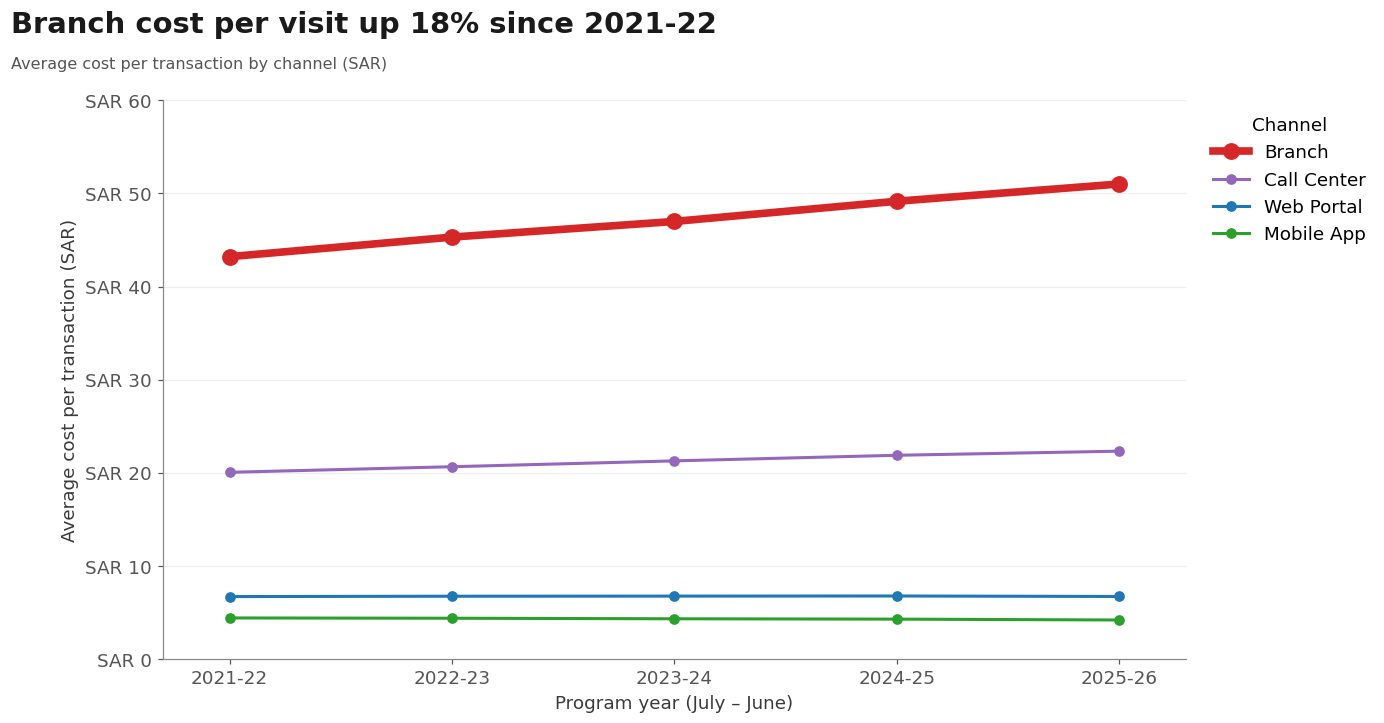

In [6]:
years = sorted(df.program_year.unique())
cpt = py["cost_per_txn"].unstack()            # rows = program year, columns = channel
visits = py.loc[(slice(None), "Branch"), "transactions"].droplevel("channel")

fig, ax = plt.subplots(figsize=(12, 6.6))
x = range(len(years))
for ch in ["Branch", "Call Center", "Web Portal", "Mobile App"]:
    main = ch == "Branch"                                  # highlight: Branch thick, others thin
    ax.plot(x, cpt[ch], color=CHANNEL_COLORS[ch], lw=5 if main else 2, marker="o",
            markersize=10 if main else 6, label=ch, zorder=4 if main else 3)
ax.legend(title="Channel", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=12, title_fontsize=12)

ax.set_xticks(list(x), [f"{y}" for y in years])
ax.set_xlim(-0.3, len(years) - 1 + 0.3)
ax.set_ylim(0, 60)
ax.yaxis.set_major_formatter(lambda v, _: f"SAR {v:.0f}")
ax.set_ylabel("Average cost per transaction (SAR)")
ax.set_xlabel("Program year (July – June)")
ax.grid(axis="y", color="#EEEEEE", lw=0.8)

add_titles(fig,
    f"Branch cost per visit up {cost_change:.0f}% since {FIRST}",
    "Average cost per transaction by channel (SAR)")
fig.savefig("charts/chart1_cost_per_transaction.png")
plt.show()

## 4. Chart 2: comparing channels (grouped bar chart)

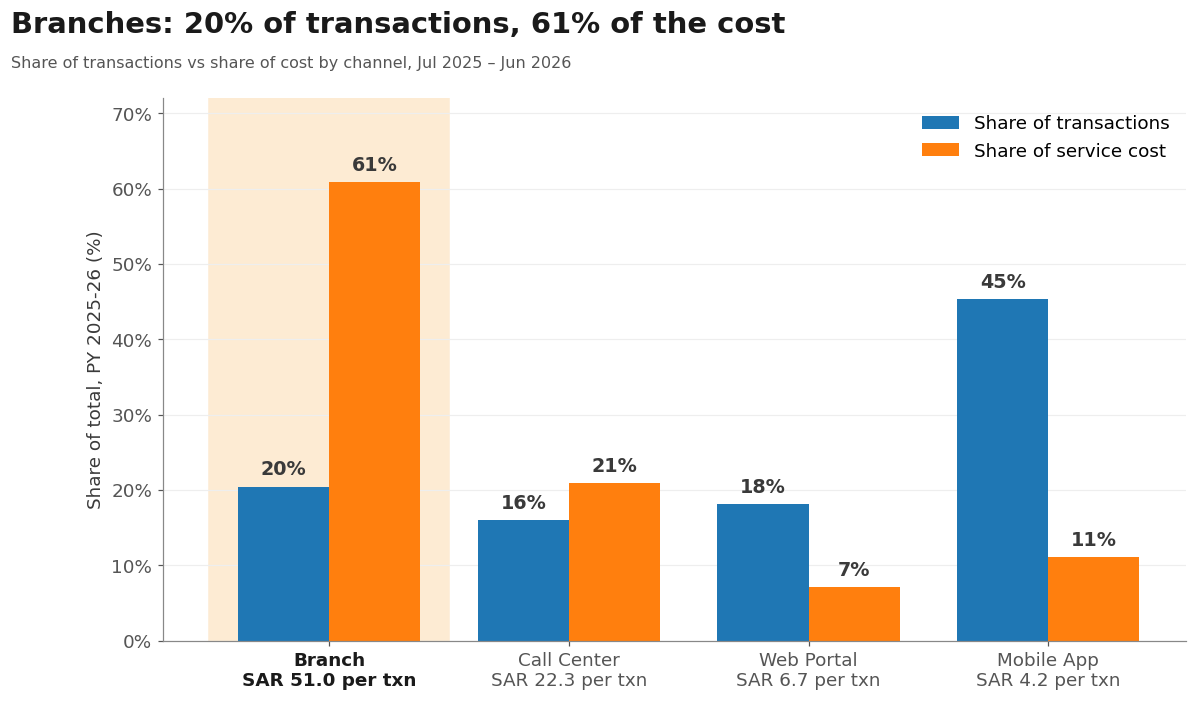

In [7]:
order = ["Branch", "Call Center", "Web Portal", "Mobile App"]
latest = py.loc[LAST].loc[order]

fig, ax = plt.subplots(figsize=(12, 6.4))
xs = np.arange(len(order)); w = 0.38
ax.axvspan(-0.5, 0.5, color="#FDEBD3", zorder=0)          # highlight: shade the Branch group
bars_tx = ax.bar(xs - w/2, latest["share_of_txn_%"],  w, color=TX_COLOR,   label="Share of transactions")
bars_cost = ax.bar(xs + w/2, latest["share_of_cost_%"], w, color=COST_COLOR, label="Share of service cost")
for bars in (bars_tx, bars_cost):
    for rect in bars:
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 1, f"{rect.get_height():.0f}%",
                ha="center", va="bottom", fontsize=12.5, weight="bold", color=DARK)

cpt_last = latest.cost_per_txn
ax.set_xticks(xs, [f"{ch}\nSAR {cpt_last[ch]:.1f} per txn" for ch in order], fontsize=12)
ax.get_xticklabels()[0].set_fontweight("bold"); ax.get_xticklabels()[0].set_color("#1A1A1A")
ax.set_ylim(0, 72)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.set_ylabel(f"Share of total, PY {LAST} (%)")
ax.legend(loc="upper right", frameon=False, fontsize=12)
ax.grid(axis="y", color="#EEEEEE", lw=0.8)
ax.set_axisbelow(True)

add_titles(fig,
    f"Branches: {latest.loc['Branch','share_of_txn_%']:.0f}% of transactions, {latest.loc['Branch','share_of_cost_%']:.0f}% of the cost",
    "Share of transactions vs share of cost by channel, Jul 2025 – Jun 2026")
fig.savefig("charts/chart2_share_of_work_vs_cost.png")
plt.show()

## 5. Checks: is the rise real, or a side effect?

1. **Is it one region or one service?** If so, the fix would be local. I check the change in branch cost per visit everywhere.
2. **Is it just a general price rise?** A general price rise would push up every channel, not mainly branches.
3. **Are only the hard cases left in branches?** If so, visits would take *longer*. I check branch completion time.

In [8]:
br = df[df.channel == "Branch"]
def unit_cost_change(by):
    g = br.groupby([by, "program_year"])[["total_cost", "transactions"]].sum()
    c = (g.total_cost / g.transactions).unstack()
    return ((c[LAST] / c[FIRST] - 1) * 100).sort_values()

reg, cat = unit_cost_change("region"), unit_cost_change("service_category")
print(f"Branch cost per visit rose in ALL {len(reg)} regions: {reg.min():+.1f}% to {reg.max():+.1f}%")
print(f"Branch cost per visit rose in ALL {len(cat)} categories: {cat.min():+.1f}% to {cat.max():+.1f}%")

Branch cost per visit rose in ALL 13 regions: +15.8% to +19.6%
Branch cost per visit rose in ALL 9 categories: +16.7% to +19.3%


In [9]:
change = pd.Series({ch: (py.loc[(LAST, ch)].cost_per_txn / py.loc[(FIRST, ch)].cost_per_txn - 1) * 100
                    for ch in order}).round(1)
print("Change in cost per transaction, PY 2021-22 -> 2025-26 (%):")
print(change.to_string())

bt = br.assign(total_min=br.avg_completion_min * br.transactions).groupby("program_year")[["total_min", "transactions"]].sum()
branch_minutes = (bt.total_min / bt.transactions).round(1)
print("\nBranch average completion time (min):")
print(branch_minutes.to_string())

Change in cost per transaction, PY 2021-22 -> 2025-26 (%):
Branch         18.0
Call Center    11.3
Web Portal      0.1
Mobile App     -5.0

Branch average completion time (min):
program_year
2021-22    40.0
2022-23    38.9
2023-24    38.3
2024-25    36.4
2025-26    35.1


In [10]:
extra = b1.transactions * (b1.cost_per_txn - b0.cost_per_txn)
print(f"PY {LAST} branch visits x (today's cost per visit - PY {FIRST} cost per visit) = SAR {extra/1e6:.0f}M")

PY 2025-26 branch visits x (today's cost per visit - PY 2021-22 cost per visit) = SAR 236M


**Results.** The rise is similar everywhere (every region and every category, roughly +16% to +20%), so it is not a local problem.
A general price rise alone does not explain it: the Mobile App got *cheaper* per transaction, the Web Portal stayed flat, and the Call Center rose less than branches (+11% vs +18%). The data cannot rule out costs that rise faster for branches (such as rent or wages).
And branch visits got *shorter*, not longer, which does not fit the idea that only the hardest cases are left.
One possible explanation is that fixed costs (buildings, staff) are now spread over far fewer visits, but the data has no cost breakdown to confirm it.

## 6. The story

**Finding.** Tayseer's branch network is getting more expensive per visit as fewer people use it.

**Evidence.**
- Branch visits fell from **56.2M** (PY 2021-22) to **30.2M** (PY 2025-26), **−46%**.
- Over the same years, cost per branch visit rose from **SAR 43.20** to **SAR 51.00**, **+18%**.
- In PY 2025-26 branches handled **20%** of transactions but took **61%** of total service cost (SAR 1.54B of SAR 2.53B).
- The rise shows in all 13 regions and all 9 categories. Over the same period, Mobile App cost per transaction fell 5%, the Web Portal stayed flat, and the Call Center rose 11%.
- At the PY 2021-22 unit cost, PY 2025-26's branch visits would have cost about **SAR 236M less**.

**Recommended action.** Before the next budget cycle, commission a **branch-network review**: find the branches whose visits
fell the most, and test merging them or turning them into smaller assisted-digital service points, while keeping in-person access
for people who need it. Track branch cost per visit every quarter, with PY 2021-22's SAR 43 as the first target.

**Limitation.** The data has no branch counts, staff numbers or cost breakdown, and the exact meaning of `cost_per_txn_sar` is not
defined, so this shows *that* branch unit cost is rising, not exactly *why*. Branches may also serve people who cannot use digital
channels (older or rural users). Closing branches too fast could cut their access, so the review should check who still relies on branches first.

## 7. Interactive dashboard (Plotly)

A one-screen interactive dashboard built in Python with Plotly. Use the **Region** dropdown in the dark header:
the number cards and the middle-row charts switch to that region. The two ranking charts always show all 13 regions, with the chosen region outlined and marked ▶.

- **Number cards:** branch cost per visit, branch visits, and branch share of service cost
- **Middle row:** cost per transaction by channel, branch visits per year, and share of transactions vs share of cost
- **Bottom row:** drop in branch visits by region, and branch cost per visit by region

All numbers use the same method as above (transactions summed, cost transaction-weighted).

In [11]:
import plotly.graph_objects as go

try:                                   # in Colab: show the whole dashboard, without a small scroll box
    from google.colab import output as colab_output
    colab_output.no_vertical_scroll()
except ImportError:
    pass

CHANNELS = ["Branch", "Call Center", "Web Portal", "Mobile App"]
NAVY, PAGE, CARD, BORDER, MUTED = "#1F2A44", "#EEF1F5", "#FFFFFF", "#DDE2EA", "#6B7280"

# ---------- numbers for one view (all regions, or one region) ----------
def view_numbers(frame):
    g = frame.groupby(["program_year", "channel"])[["transactions", "total_cost"]].sum()
    g["cpt"] = g.total_cost / g.transactions                  # transaction-weighted cost per transaction
    last = g.loc[LAST]
    return {
        "years": list(g["cpt"].unstack().index),
        "cpt": g["cpt"].unstack()[CHANNELS],
        "visits": g.loc[(slice(None), "Branch"), "transactions"].droplevel("channel"),
        "tx_share": (last.transactions / last.transactions.sum() * 100)[CHANNELS],
        "cost_share": (last.total_cost / last.total_cost.sum() * 100)[CHANNELS],
        "branch_cost": last.total_cost["Branch"], "all_cost": last.total_cost.sum(),
    }

def sar(x):                                                   # SAR 28M / SAR 1.54B
    return f"SAR {x/1e9:.2f}B" if x >= 1e9 else f"SAR {x/1e6:.0f}M"

# ---------- region rankings (the same for every view) ----------
br = df[df.channel == "Branch"].groupby(["region", "program_year"])[["total_cost", "transactions"]].sum()
br_cost = (br.total_cost / br.transactions).unstack()[LAST].sort_values()          # SAR per branch visit
br_visits = br.transactions.unstack()
br_drop = ((1 - br_visits[LAST] / br_visits[FIRST]) * 100).sort_values()         # % fall in branch visits
nat = df[df.channel == "Branch"].groupby("program_year")[["total_cost", "transactions"]].sum()
NAT_COST = nat.loc[LAST, "total_cost"] / nat.loc[LAST, "transactions"]
NAT_DROP = (1 - nat.loc[LAST, "transactions"] / nat.loc[FIRST, "transactions"]) * 100

views = {"All of Saudi Arabia": df}
views.update({r: df[df.region == r] for r in sorted(df.region.unique())})

# ---------- page grid, in pixels (converted to Plotly's 0–1 "paper" units) ----------
W, H, PAD = 1360, 960, 10
PW, PH = W - 2 * PAD, H - 2 * PAD
X = lambda px: px / PW                    # pixels from the left  -> paper x
Y = lambda px: 1 - px / PH                # pixels from the top   -> paper y
GAP = 14
col3 = [(i * ((PW - 2 * GAP) / 3 + GAP), i * ((PW - 2 * GAP) / 3 + GAP) + (PW - 2 * GAP) / 3) for i in range(3)]
col2 = [(0, (PW - GAP) / 2), ((PW - GAP) / 2 + GAP, PW)]
HEADER = (0, 64)
KPI_ROW, ROW2, ROW3 = (78, 178), (192, 542), (556, PH)

def card_shape(x0, x1, top, bottom, fill=CARD, r=10):
    """White card with rounded corners (drawn as an SVG path in paper units)."""
    rx, ry = r / PW, r / PH
    a, b, c, d = X(x0), X(x1), Y(bottom), Y(top)
    path = (f"M {a+rx},{c} L {b-rx},{c} Q {b},{c} {b},{c+ry} L {b},{d-ry} Q {b},{d} {b-rx},{d} "
            f"L {a+rx},{d} Q {a},{d} {a},{d-ry} L {a},{c+ry} Q {a},{c} {a+rx},{c} Z")
    return {"type": "path", "path": path, "xref": "paper", "yref": "paper", "fillcolor": fill,
            "line": {"color": BORDER if fill == CARD else fill, "width": 1}, "layer": "below"}

def chart_domain(x0, x1, top, bottom, left_pad, top_pad=46):
    return [X(x0 + left_pad), X(x1 - 16)], [Y(bottom - 46), Y(top + top_pad)]

shapes, ann = [], []
def text(x_px, y_px, t, size=13, color="#333", bold=False, xanchor="left", yanchor="top"):
    ann.append({"text": f"<b>{t}</b>" if bold else t, "x": X(x_px), "y": Y(y_px), "xref": "paper",
                "yref": "paper", "xanchor": xanchor, "yanchor": yanchor, "showarrow": False,
                "font": {"size": size, "color": color}, "align": "left"})
    return len(ann) - 1                                       # index, so we can update it per region

# header band
shapes.append(card_shape(0, PW, *HEADER, fill=NAVY))
text(18, 12, "Tayseer Branch Cost Dashboard", 21, "white", bold=True)
I_SUB = text(18, 40, "", 13, "#C9D1E0")
text(PW - 215, 32, "Region:", 14, "white", bold=True, xanchor="right", yanchor="middle")

# number cards
KPI = [("BRANCH COST PER VISIT", CHANNEL_COLORS["Branch"]), ("BRANCH VISITS", "#374151"),
       ("BRANCH SHARE OF SERVICE COST", COST_COLOR)]
I_VAL, I_NOTE = [], []
for (label, color), (x0, x1) in zip(KPI, col3):
    shapes.append(card_shape(x0, x1, *KPI_ROW))
    shapes.append({"type": "rect", "xref": "paper", "yref": "paper", "x0": X(x0), "x1": X(x0 + 6),
                   "y0": Y(KPI_ROW[1] - 10), "y1": Y(KPI_ROW[0] + 10), "fillcolor": color, "line": {"width": 0}})
    text(x0 + 22, KPI_ROW[0] + 12, f"{label} · PY {LAST}", 12, MUTED, bold=True)
    I_VAL.append(text(x0 + 22, KPI_ROW[0] + 30, "", 30, color, bold=True))
    I_NOTE.append(text(x0 + 22, KPI_ROW[0] + 70, "", 13, "#374151"))

# chart cards: (row, column box, left padding for axis labels, title)
CARDS = {
    "line":  (ROW2, col3[0], 70,  "Cost per transaction by channel (SAR)"),
    "visit": (ROW2, col3[1], 50,  ""),                                          # title set per region (unit)
    "share": (ROW2, col3[2], 50,  f"Share of transactions vs share of cost, PY {LAST}"),
    "drop":  (ROW3, col2[0], 120, "Drop in branch visits by region"),
    "cost":  (ROW3, col2[1], 120, f"Branch cost per visit by region, PY {LAST}"),
}
DOM, I_TITLE = {}, {}
for key, (row, (x0, x1), lpad, title) in CARDS.items():
    shapes.append(card_shape(x0, x1, *row))
    I_TITLE[key] = text(x0 + 16, row[0] + 14, title, 14, "#111827", bold=True)
    DOM[key] = chart_domain(x0, x1, *row, lpad, top_pad=66)          # room for a legend line under the title

AX = {"line": ("x", "y"), "visit": ("x2", "y2"), "share": ("x3", "y3"), "drop": ("x4", "y4"), "cost": ("x5", "y5")}

# ---------- traces: one set per region view ----------
fig = go.Figure()
layout_per_view, traces_per_view = {}, 0
for i, (region, frame) in enumerate(views.items()):
    m = view_numbers(frame)
    show = i == 0
    start = len(fig.data)
    small = m["visits"].max() < 1e6
    div, unit, dec = (1e3, "K", 0) if small else (1e6, "M", 1)

    for ch in CHANNELS:                                                        # line chart
        main = ch == "Branch"
        fig.add_trace(go.Scatter(x=m["years"], y=m["cpt"][ch], name=ch, mode="lines+markers", legend="legend",
            line={"color": CHANNEL_COLORS[ch], "width": 4.5 if main else 2}, marker={"size": 8 if main else 5},
            xaxis="x", yaxis="y", hovertemplate=f"{ch}<br>%{{x}}: SAR %{{y:.2f}}<extra></extra>", visible=show))
    fig.add_trace(go.Bar(x=m["years"], y=m["visits"] / div, marker_color=CHANNEL_COLORS["Branch"],          # visits
        text=[f"{v / div:.{dec}f}{unit}" for v in m["visits"]], textposition="outside", cliponaxis=False,
        showlegend=False, xaxis="x2", yaxis="y2", hovertemplate="%{x}: %{text}<extra></extra>", visible=show))
    for label, vals, color in [("Share of transactions", m["tx_share"], TX_COLOR),                          # shares
                               ("Share of cost", m["cost_share"], COST_COLOR)]:
        fig.add_trace(go.Bar(x=CHANNELS, y=vals, name=label, marker_color=color, legend="legend2",
            text=[f"{v:.0f}%" for v in vals], textposition="outside", cliponaxis=False,
            xaxis="x3", yaxis="y3", hovertemplate="%{x}: %{y:.1f}%<extra></extra>", visible=show))

    def ranking(values, groups, fmt, key, legend):                                                            # rankings
        xa, ya = AX[key]
        for g_name, color, test in groups:
            idx = [r for r in values.index if test(values[r])]
            fig.add_trace(go.Bar(y=idx, x=[values[r] for r in idx], orientation="h", name=g_name, legend=legend,
                marker={"color": color, "line": {"color": ["#111" if r == region else color for r in idx],
                                                 "width": [3 if r == region else 0 for r in idx]}},
                text=[fmt(values[r]) for r in idx], textposition="outside", cliponaxis=False,
                textfont={"color": "#111827", "size": 12}, xaxis=xa, yaxis=ya, offsetgroup=key,   # one full-width bar per region
                hovertemplate="%{y}: %{text}<extra></extra>", visible=show))
    ranking(br_drop, [(f"Dropped more than Saudi Arabia overall (−{NAT_DROP:.1f}%)", "#1F77B4", lambda v: v >= NAT_DROP),
                      ("Dropped less than Saudi Arabia overall", "#FF7F0E", lambda v: v < NAT_DROP)],
            lambda v: f"−{v:.1f}%", "drop", "legend3")
    ranking(br_cost, [(f"Costs more than the Saudi average (SAR {NAT_COST:.1f})", "#D62728", lambda v: v >= NAT_COST),
                      ("Costs less than the Saudi average", "#2CA02C", lambda v: v < NAT_COST)],
            lambda v: f"SAR {v:.1f}", "cost", "legend4")
    traces_per_view = len(fig.data) - start

    # per-region text and axis settings (applied by the dropdown)
    c0, c1 = m["cpt"].loc[FIRST, "Branch"], m["cpt"].loc[LAST, "Branch"]
    v0, v1 = m["visits"].loc[FIRST], m["visits"].loc[LAST]
    ymax = m["cpt"]["Branch"].max() * 1.15
    bold = lambda order: [f"<b>{r} ▶</b>" if r == region else r for r in order]
    layout_per_view[region] = {
        f"annotations[{I_SUB}].text": f"{region} · Branch visits are falling, but each visit costs more · "
                                      f"Program years run July–June",
        f"annotations[{I_VAL[0]}].text": f"<b>SAR {c1:.1f}</b>",
        f"annotations[{I_NOTE[0]}].text": f"▲ {(c1 / c0 - 1) * 100:.0f}% vs PY {FIRST} (SAR {c0:.1f})",
        f"annotations[{I_VAL[1]}].text": f"<b>{v1 / div:.{dec}f}{unit}</b>",
        f"annotations[{I_NOTE[1]}].text": f"▼ {(1 - v1 / v0) * 100:.0f}% vs PY {FIRST} ({v0 / div:.{dec}f}{unit})",
        f"annotations[{I_VAL[2]}].text": f"<b>{m['cost_share']['Branch']:.0f}%</b>",
        f"annotations[{I_NOTE[2]}].text": f"{sar(m['branch_cost'])} of {sar(m['all_cost'])} · "
                                          f"only {m['tx_share']['Branch']:.0f}% of transactions",
        f"annotations[{I_TITLE['visit']}].text": f"<b>Branch visits per year ({'thousands' if small else 'millions'})</b>",
        "yaxis.range": [0, ymax],
        "yaxis2.range": [0, v0 / div * 1.25],
        "yaxis3.range": [0, max(m["tx_share"].max(), m["cost_share"].max()) * 1.2],
        "yaxis4.ticktext": bold(br_drop.index),
        "yaxis5.ticktext": bold(br_cost.index),
    }

# ---------- region dropdown (inside the figure, in the header) ----------
buttons = []
for i, region in enumerate(views):
    vis = [False] * len(fig.data)
    vis[i * traces_per_view:(i + 1) * traces_per_view] = [True] * traces_per_view
    buttons.append({"label": region, "method": "update", "args": [{"visible": vis}, layout_per_view[region]]})

# ---------- stripes and highlight ----------
for key, order in [("drop", br_drop.index), ("cost", br_cost.index)]:
    xa, ya = AX[key]
    for k in range(1, len(order), 2):
        shapes.append({"type": "rect", "xref": f"{xa} domain", "yref": ya, "x0": 0, "x1": 1, "y0": k - 0.5,
                       "y1": k + 0.5, "fillcolor": "#F3F4F6", "line": {"width": 0}, "layer": "below"})
shapes.append({"type": "rect", "xref": "x3", "yref": "y3 domain", "x0": -0.5, "x1": 0.5, "y0": 0, "y1": 1,
               "fillcolor": "#FDEBD3", "line": {"width": 0}, "layer": "below"})

# ---------- axes ----------
grid = {"gridcolor": "#EEF0F3", "zeroline": False, "linecolor": "#D1D5DB", "tickfont": {"size": 11}}
def axis(key, **kw):
    (x0, x1), (y0, y1) = DOM[key]
    xa, ya = AX[key]
    xn, yn = "xaxis" + xa[1:], "yaxis" + ya[1:]
    return {xn: {"domain": [x0, x1], "anchor": ya, **grid, **kw.get("x", {})},
            yn: {"domain": [y0, y1], "anchor": xa, **grid, **kw.get("y", {})}}

axes = {}
axes.update(axis("line", x={"title": {"text": "Program year (July–June)", "font": {"size": 11}}},
                 y={"tickprefix": "SAR ", "rangemode": "tozero"}))
axes.update(axis("visit", x={"title": {"text": "Program year", "font": {"size": 11}}}, y={"rangemode": "tozero"}))
axes.update(axis("share", y={"ticksuffix": "%", "rangemode": "tozero"}))
axes.update(axis("drop", x={"title": {"text": f"% drop in branch visits, PY {FIRST} → {LAST}", "font": {"size": 11}},
                            "ticksuffix": "%", "range": [0, br_drop.max() * 1.15]},
                 y={"categoryorder": "array", "categoryarray": list(br_drop.index), "tickvals": list(br_drop.index),
                    "showgrid": False}))
axes.update(axis("cost", x={"title": {"text": f"SAR per branch visit, PY {LAST}", "font": {"size": 11}},
                            "tickprefix": "SAR ", "range": [0, br_cost.max() * 1.15]},
                 y={"categoryorder": "array", "categoryarray": list(br_cost.index), "tickvals": list(br_cost.index),
                    "showgrid": False}))

# ---------- page layout ----------
fig.update_layout(
    width=W, height=H, autosize=False, margin={"l": PAD, "r": PAD, "t": PAD, "b": PAD},
    paper_bgcolor=PAGE, plot_bgcolor=CARD, font={"family": "Arial", "size": 12, "color": "#333"},
    barmode="group", bargap=0.22, shapes=shapes, annotations=ann, **axes,
    updatemenus=[{"buttons": buttons, "direction": "down", "x": X(PW - 16), "xanchor": "right",
                  "y": Y(17), "yanchor": "top", "bgcolor": "white", "bordercolor": "#9CA3AF",
                  "font": {"size": 13, "color": "#111"}, "pad": {"t": 0, "b": 0, "l": 0, "r": 0}}],
    legend={"x": X(col3[0][0] + 10), "y": Y(ROW2[0] + 36), "xanchor": "left", "yanchor": "top",
            "orientation": "h", "font": {"size": 11}, "bgcolor": "rgba(0,0,0,0)", "itemwidth": 30},
    legend2={"x": X(col3[2][0] + 10), "y": Y(ROW2[0] + 36), "xanchor": "left", "yanchor": "top",
             "orientation": "h", "font": {"size": 11}, "bgcolor": "rgba(0,0,0,0)"},
    legend3={"x": X(col2[0][0] + 10), "y": Y(ROW3[0] + 36), "xanchor": "left", "yanchor": "top",
             "orientation": "h", "font": {"size": 12}, "bgcolor": "rgba(0,0,0,0)"},
    legend4={"x": X(col2[1][0] + 10), "y": Y(ROW3[0] + 36), "xanchor": "left", "yanchor": "top",
             "orientation": "h", "font": {"size": 12}, "bgcolor": "rgba(0,0,0,0)"},
    hoverlabel={"font": {"size": 12}},
)
fig.update_layout(**{k.replace(".", "_").replace("[", "_").replace("]", ""): v
                     for k, v in layout_per_view["All of Saudi Arabia"].items() if not k.startswith("annotations")})
for k, v in layout_per_view["All of Saudi Arabia"].items():          # fill the per-region text for the first view
    if k.startswith("annotations"):
        idx = int(k[k.index("[") + 1:k.index("]")])
        fig.layout.annotations[idx].text = v

fig.show(config={"displayModeBar": False})